<a href="https://colab.research.google.com/github/djnena/Branko_Jankovic_Task4/blob/main/notebooks/Branko_Jankovic_Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task - Predikcija cene polovnih automobila


Cilj ove analize je da istrazimo podatke o automobilima i utvrdimo od kojih karakteristika zavisi njihova cena (priceUSD).

Konkretno, zelimo da:

- upoznamo strukturu i sadrzaj podataka;
- proverimo kvalitet podataka, ukljucujuci nedostajuce vrednosti;
- razlikujemo numericke i kategorijske podatke;
- analiziramo ciljnu promenljivu priceUSD;
- pronadjemo moguce ekstremne vrednosti;
- ispitamo karakteristike automobila poput godista, kilometraze, zapremine motora, goriva, menjaca, pogona i proizvodjaca;
- pripremimo podatke za kasniju analizu i predvidjanje cene automobila.

##1. Uvoz biblioteka

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

##2. Definisanje putanje

In [6]:
# load dataset from GitHub
DATA_PATH = "https://raw.githubusercontent.com/djnena/Branko_Jankovic_Task4/main/data/cars.csv"
DATA_PATH

'https://raw.githubusercontent.com/djnena/Branko_Jankovic_Task4/main/data/cars.csv'

##3. Ucitavanje podataka

In [7]:
df = pd.read_csv(DATA_PATH)

##4. Analiza broja redova i kolona

U skupu podataka cars.csv nalazi se:

56.244 redova
12 kolona

Svaki red predstavlja jedan automobil, odnosno jedan zapis o automobilu. Svaka kolona predstavlja odredjenu karakteristiku automobila, kao sto su proizvodjac, model, cena, godiste, kilometraza, tip goriva i slicno.

Dakle, skup podataka je dimenzija 56.244 × 12.

In [8]:
df.shape

(56244, 12)

##5. Tipovi podataka

Nakon ucitavanja podataka potrebno je proveriti kog su tipa podaci u svakoj koloni. Ovo je vazno jer od tipa podatka zavisi koju vrstu analize mozemo da primenimo.

In [9]:
df.dtypes

,0
make,object
model,object
priceUSD,int64
year,int64
condition,object
mileage(kilometers),float64
fuel_type,object
volume(cm3),float64
color,object
transmission,object


Mozemo ih podeliti na:

- Numericke kolone:

  - priceUSD
  - year
  - mileage(kilometers)
  - volume(cm3)

- Kategorijske kolone:

  - make
  - model
  - condition
  - fuel_type
  - color
  - transmission
  - drive_unit
  - segment

##6. Nedostajuce vrednosti

Nakon provere tipova podataka potrebno je proveriti da li u skupu postoje nedostajuce vrednosti. Nedostajuca vrednost znaci da za odredjeni automobil neka informacija nije unesena.

In [10]:
df.isnull().sum()

,0
make,0
model,0
priceUSD,0
year,0
condition,0
mileage(kilometers),0
fuel_type,0
volume(cm3),47
color,0
transmission,0


Za ovaj skup podataka ukupno postoji 7.243 nedostajuce vrednosti.

Ova analiza je vazna zato sto nedostajuci podaci mogu uticati na rezultate kasnije analize. Pre izgradnje modela ili donosenja zakljucaka potrebno je odluciti da li cemo takve vrednosti obrisati, popuniti odgovarajucom vrednoscu ili ih ostaviti nepromenjene.

##7. ciljne promenljive priceUSD

Ciljna promenljiva u ovom skupu podataka je priceUSD, koja predstavlja cenu automobila izrazenu u americkim dolarima (USD).

Prvo mozemo proveriti osnovne informacije o ovoj promenljivoj:

In [11]:
df["priceUSD"].describe()

,priceUSD
count,56244.000000
mean,7415.456440
std,8316.959261
min,48.000000
25%,2350.000000
50%,5350.000000
75%,9807.500000
max,235235.000000


Dobijamo osnovne statisticke pokazatelje kao sto su:

- count – broj automobila za koje postoji cena;
- mean – prosecna cena automobila;
- std – standardna devijacija;
- min – najniza cena;
- 25% – prvi kvartil;
- 50% – medijana;
- 75% – treci kvartil;
- max – najvisa cena.

Za vizuelni prikaz distribucije cena mozemo koristiti histogram:

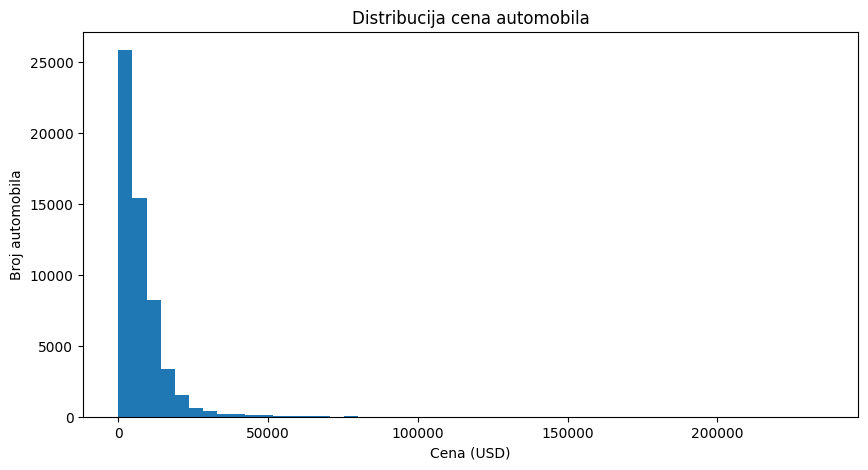

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df["priceUSD"].dropna(), bins=50)
plt.xlabel("Cena (USD)")
plt.ylabel("Broj automobila")
plt.title("Distribucija cena automobila")
plt.show()

Histogram nam pokazuje kako su cene rasporedjene. Mozemo videti da li se vecina automobila nalazi u odredjenom cenovnom rasponu i da li postoje automobili sa veoma visokim cenama.

## 8. Numericke kolone

Numericke kolone su kolone cije vrednosti predstavljaju brojeve. One su vazne za statisticku analizu jer mozemo racunati prosecne vrednosti, minimum, maksimum, medijanu i druge pokazatelje.

U nasem skupu podataka numericke kolone su:

- priceUSD – cena automobila u USD
- year – godina proizvodnje
- mileage(kilometers) – predjena kilometraza
- volume(cm3) – zapremina motora u cm³

Numericke kolone mozemo izdvojiti pomocu:

In [16]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numericke kolone:")
print(numeric_columns)

df[numeric_columns].describe()

Numericke kolone:
Index(['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)'], dtype='object')


,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.000000,56244.000000,5.624400e+04,56197.000000
mean,7415.456440,2003.454840,2.443956e+05,2104.860615
std,8316.959261,8.144247,3.210307e+05,959.201633
min,48.000000,1910.000000,0.000000e+00,500.000000
25%,2350.000000,1998.000000,1.370000e+05,1600.000000
50%,5350.000000,2004.000000,2.285000e+05,1996.000000
75%,9807.500000,2010.000000,3.100000e+05,2300.000000
max,235235.000000,2019.000000,9.999999e+06,20000.000000


##9. Kategorijske kolone

Kategorijske kolone sadrze tekstualne podatke, odnosno opisuju razlicite karakteristike automobila. Za razliku od numerickih kolona, njihove vrednosti predstavljaju kategorije ili grupe.

U nasem skupu podataka kategorijske kolone su:

- make – proizvodjac automobila
- model – model automobila
- condition – stanje automobila
- fuel_type – vrsta goriva
- color – boja automobila
- transmission – tip menjaca
- drive_unit – vrsta pogona
- segment – segment automobila

Kategorijske kolone mozemo izdvojiti pomocu:

In [17]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Kategorijske kolone:")
print(categorical_columns)

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} različitih kategorija")

Kategorijske kolone:
Index(['make', 'model', 'condition', 'fuel_type', 'color', 'transmission',
       'drive_unit', 'segment'],
      dtype='object')
make: 96 različitih kategorija
model: 1034 različitih kategorija
condition: 3 različitih kategorija
fuel_type: 3 različitih kategorija
color: 13 različitih kategorija
transmission: 2 različitih kategorija
drive_unit: 4 različitih kategorija
segment: 9 različitih kategorija


##10. Ekstremne vrednosti

Ekstremne vrednosti, odnosno outlieri, predstavljaju vrednosti koje se znacajno razlikuju od vecine ostalih podataka. Na primer, automobil sa veoma visokom cenom ili neuobicajeno velikom kilometrazom moze predstavljati ekstremnu vrednost.

Za pronalazenje ekstremnih vrednosti koristicemo IQR metodu (Interquartile Range).

In [18]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nKolona: {col}")
    print(f"Donja granica: {lower_bound:.2f}")
    print(f"Gornja granica: {upper_bound:.2f}")
    print(f"Broj ekstremnih vrednosti: {len(outliers)}")


Kolona: priceUSD
Donja granica: -8836.25
Gornja granica: 20993.75
Broj ekstremnih vrednosti: 2551

Kolona: year
Donja granica: 1980.00
Gornja granica: 2028.00
Broj ekstremnih vrednosti: 258

Kolona: mileage(kilometers)
Donja granica: -122500.00
Gornja granica: 569500.00
Broj ekstremnih vrednosti: 689

Kolona: volume(cm3)
Donja granica: 550.00
Gornja granica: 3350.00
Broj ekstremnih vrednosti: 3618


Posebno su zanimljive vrednosti kao sto su 9.999.999 km kilometraze i 20.000 cm³ zapremine motora, jer deluju veoma neuobicajeno za standardne automobile i trebalo bi ih dodatno proveriti.

Kod year postoji vrednost 1910, koja je takodje neuobicajena u poredjenju sa vecinom automobila u skupu.

Kod priceUSD postoji automobil sa cenom od cak 235.235 USD, sto je ekstremna vrednost prema IQR metodi, ali ne mora nuzno biti greska — moze predstavljati veoma skup automobil.